# De Novo Design of Potential CCR2 Binders with DrugEx and ROCS Shape-Based Scoring

 This tutorial demonstrates the use of DrugEx with shape-based scoring using ROCS (Rapid Overlay of Chemical Structures).
* We will fine-tune a pretrained RNN model on CCR2 ligand data and then use reinforcement learning with shape-based 
* similarity objectives (using RDKit, CDPKit, or OpenEye implementations) combined with synthetic accessibility (SA) scores.


In [1]:

import torch

# Check if CUDA is available (optional, can run on CPU as well)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch version: 2.9.0+cu128
CUDA available: True


In [2]:
# ==============================================================================
# CONFIGURATION: Toggle Model Training
# ==============================================================================

# Set to True to use existing models (skip training)
# Set to False to train from scratch (will delete existing models)
USE_EXISTING_MODELS = False  

# Individual controls (only used if USE_EXISTING_MODELS = True)
USE_EXISTING_FINETUNED = True  # Skip fine-tuning if model exists
USE_EXISTING_RL_MODELS = True  # Skip RL training if models exist

print("Configuration:")
print(f"  USE_EXISTING_MODELS: {USE_EXISTING_MODELS}")
if USE_EXISTING_MODELS:
    print(f"  - Use existing fine-tuned model: {USE_EXISTING_FINETUNED}")
    print(f"  - Use existing RL models: {USE_EXISTING_RL_MODELS}")
else:
    print("  - Will train all models from scratch")


Configuration:
  USE_EXISTING_MODELS: False
  - Will train all models from scratch


# ROCS-Based RNN for CCR2 Ligand Design

This notebook demonstrates the application of DrugEx with shape-based scoring for designing potential CCR2 (C-C Chemokine Receptor 2) ligands. We compare three ROCS implementations (RDKit, CDPKit, and OpenEye) for 3D molecular similarity scoring.

## Workflow Overview

1. **Data Loading**: Import CCR2 ligand bioactivity data and standardize SMILES
2. **Data Encoding**: Encode molecules using pretrained vocabulary and split into train/test sets
3. **Fine-Tuning**: Transfer learning from general pretrained model to CCR2-specific model
4. **Scoring Setup**: Configure ROCS shape similarity and synthetic accessibility objectives
5. **Reinforcement Learning**: Train models to optimize both objectives using Pareto optimization
6. **Generation**: Generate novel molecules and evaluate performance across backends

## Imports and Paths

In [3]:
import os
from pathlib import Path
import shutil
import time
import warnings

import numpy as np
import pandas as pd
import torch

from drugex.data.corpus.vocabulary import VocSmiles
from drugex.training.generators import SequenceRNN
from drugex.training.monitors import FileMonitor
from drugex.training.explorers import SequenceExplorer
from drugex.training.environment import DrugExEnvironment
from drugex.training.rewards import ParetoCrowdingDistance
from drugex.training.scorers.modifiers import SmoothClippedScore
from drugex.training.scorers.properties import Property
from drugex.training.scorers.conformer_generators import RDKitConformerGenerator
from drugex.logs import logger

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
logger.setLevel('ERROR')

try:
    from drugex.training.scorers.conformer_generators import CDPKitConformerGenerator
    from drugex.training.scorers.cdpkit_rocs import CDPKitROCSScorer
    CDPKIT_READY = True
except ImportError:
    CDPKitConformerGenerator = None
    CDPKitROCSScorer = None
    CDPKIT_READY = False

try:
    from drugex.training.scorers.conformer_generators import OmegaConformerGenerator
    from drugex.training.scorers.cli_rocs import CLIROCSScorer
    OPENEYE_READY = True
except ImportError:
    OmegaConformerGenerator = None
    CLIROCSScorer = None
    OPENEYE_READY = False

from drugex.training.scorers.rdkit_rocs import RDKitROCSScorer

# Set random seeds for reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Define paths
ROOT = Path.cwd()
RES = ROOT / 'rocs_rl_ccr/rdkit_cdpkit'
CCR2_TSV = RES / 'CCR_HUMAN_AL.tsv'
CCR2_SDF = RES / 'CCR2_reference_ligands.sdf'
MODEL_DIR = ROOT / 'demo_out/models'
RUN_DIR = ROOT / 'rl_runs_demo'
DATA_DIR = ROOT / 'demo_out/datasets/encoded/rnn/'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
ROCS_BINARY = shutil.which('rocs') if OPENEYE_READY else None

# Path to pretrained model
MODELS_PR_PATH = "../data/models/pretrained/smiles-rnn/Papyrus05.5_smiles_rnn_PT/"

# Training parameters
N_PROCESSES = 20  # number of CPU cores to use
CHUNK_SIZE = 1000  # largest chunk per CPU core (regulates RAM usage)
BATCH_SIZE = 256  # batch size for training

print(f"CCR2 data: {CCR2_TSV.exists()}")
print(f"CCR2 reference SDF: {CCR2_SDF.exists()}")
print(f"Pretrained model path: {Path(MODELS_PR_PATH).exists()}")
print(f"CDPKit available: {CDPKIT_READY}")
print(f"OpenEye available: {OPENEYE_READY and ROCS_BINARY is not None}")

CCR2 data: True
CCR2 reference SDF: True
Pretrained model path: True
CDPKit available: True
OpenEye available: True


## Loading and Preparing CCR2 Ligand Data

We start by loading CCR2 ligand data and standardizing the SMILES strings using DrugEx's standardization pipeline.

In [4]:
from drugex.data.processing import Standardization

# Load CCR2 ligand data
df_ccr2 = pd.read_table(CCR2_TSV)
print(f"Loaded {len(df_ccr2)} CCR2 ligands")

# Standardize SMILES strings
standardizer = Standardization(n_proc=N_PROCESSES, chunk_size=CHUNK_SIZE)
smiles_ft = standardizer.apply(df_ccr2.SMILES)
print(f"Standardized {len(smiles_ft)} SMILES")
smiles_ft[0:10]

Loaded 1021 CCR2 ligands


Standardizing molecules (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Standardized 1021 SMILES


['COc1nc(Br)cnc1NS(=O)(=O)c1sc(Cl)cc1Br',
 'COc1nc(Br)cnc1NS(=O)(=O)c1cc(Cl)c(Cl)s1',
 'COc1nc(Cl)cnc1NS(=O)(=O)c1scc(Cl)c1Cl',
 'COc1nc(Cl)c(Cl)nc1NS(=O)(=O)c1ccc(Cl)s1',
 'CSc1nc(Br)cnc1NS(=O)(=O)c1ccc(Cl)s1',
 'COc1nc(Br)cnc1NS(=O)(=O)c1ccc(Cl)s1',
 'COc1nc(Br)cnc1NS(=O)(=O)c1ccc(Cl)s1',
 'COc1nccnc1NS(=O)(=O)c1scc(Cl)c1Cl',
 'CNc1nc(Br)cnc1NS(=O)(=O)c1ccc(Cl)s1',
 'COc1nc(Br)cnc1NS(=O)(=O)c1ccsc1']

In [5]:
from drugex.data.processing import CorpusEncoder, RandomTrainTestSplitter
from drugex.data.corpus.corpus import SequenceCorpus
from drugex.data.datasets import SmilesDataSet

# Load vocabulary from pretrained model
voc = VocSmiles.fromFile(f"{MODELS_PR_PATH}/Papyrus05.5_smiles_rnn_PT.vocab", encode_frags=False)

# Encode SMILES data using the vocabulary
encoder = CorpusEncoder(
    SequenceCorpus,  # The corpus class implements how each SMILES string is divided into tokens
    {
        'vocabulary': voc,  # use pretrained vocabulary
        'update_voc': False,  # keep vocabulary fixed (no new tokens added)
        'throw': True  # discard compounds containing unknown tokens
    },
    n_proc=N_PROCESSES,
    chunk_size=CHUNK_SIZE
)

# Collect encoded data
data_collector = SmilesDataSet(os.path.join(DATA_DIR, 'ccr2_ligand_corpus.tsv'), rewrite=True)
encoder.apply(smiles_ft, collector=data_collector)
print(f"Encoded {len(data_collector.getData())} molecules")

# Split into train/test sets
splitter = RandomTrainTestSplitter(0.05, 1e4)
train, test = splitter(data_collector.getData())

# Create train and test datasets
for data, name in zip([train, test], ['train', 'test']):
    file_path = os.path.join(DATA_DIR, f'ccr2_{name}.tsv')
    pd.DataFrame(data).to_csv(file_path, header=True, index=False, sep='\t')
    print(f"Saved {len(data)} molecules to {name} set")

# Create data loaders
data_set_train = SmilesDataSet(os.path.join(DATA_DIR, 'ccr2_train.tsv'), voc=voc)
data_set_test = SmilesDataSet(os.path.join(DATA_DIR, 'ccr2_test.tsv'), voc=voc)
loader_train = data_set_train.asDataLoader(batch_size=BATCH_SIZE)
loader_test = data_set_test.asDataLoader(batch_size=BATCH_SIZE)

print(f"\nTrain batches: {len(loader_train)}, Test batches: {len(loader_test)}")

SequenceCorpus (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Encoded 879 molecules
Saved 835 molecules to train set
Saved 44 molecules to test set

Train batches: 4, Test batches: 1


## Fine-Tuning with Transfer Learning

We fine-tune the pretrained Papyrus model on our CCR2-specific data using transfer learning. This allows the model to learn CCR2-relevant chemical space while retaining general chemical knowledge.

In [6]:
# Check if we should skip fine-tuning
finetune_checkpoint = os.path.join(MODEL_DIR, 'CCR2_finetuned.pkg')
vocab_checkpoint = os.path.join(MODEL_DIR, 'CCR2_finetuned.vocab')

skip_finetuning = (
    USE_EXISTING_MODELS and 
    USE_EXISTING_FINETUNED and 
    os.path.exists(finetune_checkpoint) and
    os.path.exists(vocab_checkpoint)
)

if skip_finetuning:
    print("=" * 60)
    print("SKIPPING FINE-TUNING - Using existing model")
    print("=" * 60)
    print(f"Loading from: {finetune_checkpoint}")
    
    # Load vocabulary
    voc = VocSmiles.fromFile(vocab_checkpoint, encode_frags=False)
    print("Vocabulary loaded successfully")
else:
    print("=" * 60)
    print("TRAINING NEW FINE-TUNED MODEL")
    print("=" * 60)
    
    # Initialize model and load pretrained weights
    ft_path = os.path.join(MODEL_DIR, 'CCR2_finetuned')
    finetuned = SequenceRNN(voc, is_lstm=True)
    finetuned.loadStatesFromFile(os.path.join(MODELS_PR_PATH, 'Papyrus05.5_smiles_rnn_PT.pkg'))
    
    # Set up monitoring
    monitor = FileMonitor(ft_path, save_smiles=True, reset_directory=True)
    
    # Train the model
    start = time.time()
    finetuned.fit(loader_train, loader_test, epochs=100, monitor=monitor, patience=30)
    monitor.close()
    
    # Save vocabulary
    voc.toFile(vocab_checkpoint)
    
    print(f'\nFine-tuning completed in {time.time() - start:.1f}s')
    print(f'Model saved to: {finetune_checkpoint}')

TRAINING NEW FINE-TUNED MODEL


Fitting model:   0%|          | 0/100 [00:00<?, ?it/s]


Fine-tuning completed in 160.8s
Model saved to: /home/ubuntu/DrugEx-ROCS-private/tutorial/rocs/demo_out/models/CCR2_finetuned.pkg



Training metrics (last 5 epochs):
    Epoch  loss_train  loss_valid  valid_ratio  best_epoch
56     57       0.076       0.144        0.934          30
57     58       0.074       0.144        0.916          30
58     59       0.075       0.143        0.926          30
59     60       0.074       0.143        0.930          30
60     61       0.074       0.144        0.939          30


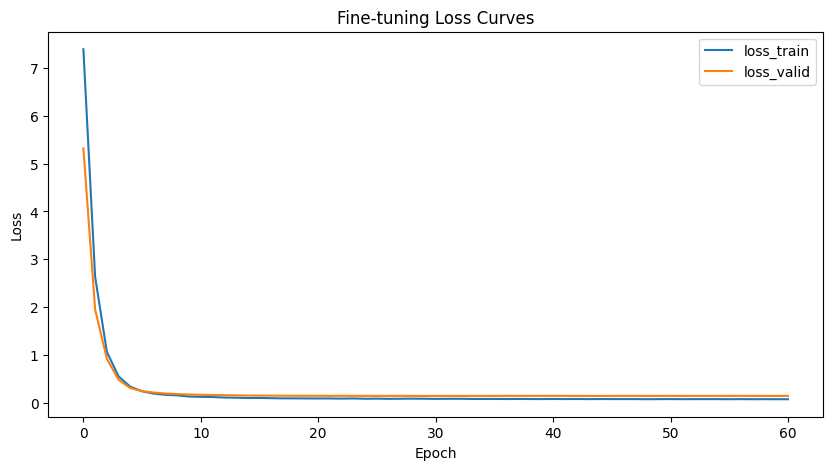

In [7]:
# Visualize training progress
if not skip_finetuning:
    df_ft_info = pd.read_csv(f'{MODEL_DIR}/CCR2_finetuned_fit.tsv', sep='\t')
    print("\nTraining metrics (last 5 epochs):")
    print(df_ft_info.tail())
    
    # Plot training curves
    df_ft_info[['loss_train', 'loss_valid']].plot.line(
        title='Fine-tuning Loss Curves',
        xlabel='Epoch',
        ylabel='Loss',
        figsize=(10, 5)
    )
else:
    # Load existing training data if available
    fit_file = f'{MODEL_DIR}/CCR2_finetuned_fit.tsv'
    if os.path.exists(fit_file):
        df_ft_info = pd.read_csv(fit_file, sep='\t')
        print("\nExisting model training metrics (last 5 epochs):")
        print(df_ft_info.tail())
        
        # Plot training curves
        df_ft_info[['loss_train', 'loss_valid']].plot.line(
            title='Fine-tuning Loss Curves (Existing Model)',
            xlabel='Epoch',
            ylabel='Loss',
            figsize=(10, 5)
        )
    else:
        print("Note: Fine-tuning history not available for visualization")


## Defining Scoring Functions and RL Environments

We define scoring functions for our reinforcement learning objectives:
1. **Shape-based similarity (ROCS)**: Measures 3D shape and pharmacophore similarity to known CCR2 ligands
2. **Synthetic Accessibility (SA)**: Favors molecules that are easier to synthesize (lower SA scores are better)

We configure three different ROCS implementations for comparison:
- **RDKit**: Open-source
- **CDPKit**: Open-source
- **OpenEye CLI**: Commercial

In [8]:
def sa_scorer():
    """Create synthetic accessibility scorer with smooth clipping"""
    sa = Property('SA')
    # Lower SA scores are better (simpler molecules)
    # Score smoothly transitions from 1 (best) at SA=3 to 0 (worst) at SA=5
    sa.setModifier(SmoothClippedScore(lower_x=5, upper_x=3))
    return sa


def env_rdkit():
    """Create environment with RDKit ROCS scorer"""
    scorer = RDKitROCSScorer(
        RDKitConformerGenerator(max_conformers=20, max_centers=2, max_heavy_atoms=40),
        str(CCR2_SDF),
        'TanimotoCombo',
        True,  # use best conformer
        False,  # not shape only
        -1,  # n_jobs = -1 ; use all cpus
    )
    # Thresholds: [0.45 for ROCS TanimotoCombo, 0.1 for SA]
    env = DrugExEnvironment([scorer, sa_scorer()], [0.45, 0.1], ParetoCrowdingDistance())
    return scorer, env


def env_cdpkit():
    """Create environment with CDPKit ROCS scorer"""
    if not CDPKIT_READY:
        raise RuntimeError('CDPKit bindings not available')
    scorer = CDPKitROCSScorer(
        CDPKitConformerGenerator(max_conformers=20, max_centers=2, max_heavy_atoms=40),
        str(CCR2_SDF),
        False,  # not shape only
        -1,  # n_jobs = -1 ; use all cpus
    )
    env = DrugExEnvironment([scorer, sa_scorer()], [0.45, 0.1], ParetoCrowdingDistance())
    return scorer, env


def env_cli():
    """Create environment with OpenEye CLI ROCS scorer"""
    if not (OPENEYE_READY and ROCS_BINARY):
        raise RuntimeError('OpenEye ROCS CLI not available')
    scorer = CLIROCSScorer(
        conformer_generator=OmegaConformerGenerator(
            max_conformers=20, max_centers=2, max_heavy_atoms=40, 
            use_gpu=False, show_progress=False
        ),
        query_files={'CCR2': str(CCR2_SDF)},
        score_type='TanimotoCombo',
        shape_only=False,
        optimize=True,
        color_optimize=True,
        rocs_binary=ROCS_BINARY,
        show_progress=False,
    )
    env = DrugExEnvironment([scorer, sa_scorer()], [0.45, 0.1], ParetoCrowdingDistance())
    return scorer, env


# Build list of available backends
builders = [('rdkit', env_rdkit, RUN_DIR / 'rdkit_rl')]
if CDPKIT_READY:
    builders.append(('cdpkit', env_cdpkit, RUN_DIR / 'cdpkit_rl'))
if OPENEYE_READY and ROCS_BINARY:
    builders.append(('cli', env_cli, RUN_DIR / 'cli_rl'))

print(f"Available backends: {[name for name, _, _ in builders]}")
pd.DataFrame([{ 'backend': name, 'output_dir': str(path) } for name, _, path in builders])

Available backends: ['rdkit', 'cdpkit', 'cli']


,backend,output_dir
0,rdkit,/home/ubuntu/DrugEx-ROCS-private/tutorial/rocs...
1,cdpkit,/home/ubuntu/DrugEx-ROCS-private/tutorial/rocs...
2,cli,/home/ubuntu/DrugEx-ROCS-private/tutorial/rocs...


## Reinforcement Learning with Multi-Objective Optimization

We now train our model using reinforcement learning to optimize for both shape similarity and synthetic accessibility simultaneously. The RL process uses:
- **Agent (exploitation network)**: Starts from pretrained model, gets trained
- **Mutate (exploration network)**: Finetuned model, provides diversity via epsilon-greedy sampling
- **Epsilon**: Controls exploration rate (0.4 = 40% tokens from finetuned model)
- **Pareto optimization**: Balances multiple objectives without requiring manual weighting

Each backend (RDKit, CDPKit, OpenEye) will be trained separately to allow comparison.

In [9]:
results = []

# Train RL model for each backend separately
for name, builder, out_dir in builders:
    print(f"\n{'='*60}")
    print(f"Backend: {name.upper()}")
    print(f"{'='*60}")
    
    out_dir.mkdir(parents=True, exist_ok=True)
    rl_path = os.path.join(out_dir, f'CCR2_{name}_reinforced')
    rl_checkpoint = f'{rl_path}.pkg'
    rl_fit_file = f'{rl_path}_fit.tsv'
    
    # Check if we should skip RL training for this backend
    skip_rl = (
        USE_EXISTING_MODELS and 
        USE_EXISTING_RL_MODELS and 
        os.path.exists(rl_checkpoint) and
        os.path.exists(rl_fit_file)
    )
    
    if skip_rl:
        print(f"SKIPPING RL TRAINING - Using existing model")
        print(f"Model: {rl_checkpoint}")

        
        results.append({
            'backend': name,
            'fit_path': rl_fit_file,
            'checkpoint': rl_checkpoint,
        })
    else:
        print(f"TRAINING NEW RL MODEL")
        
        # Build environment
        _, env = builder()
        
        # Load pretrained model as agent (exploitation network - will be trained)
        agent = SequenceRNN(voc, is_lstm=True)
        agent.loadStatesFromFile(os.path.join(MODELS_PR_PATH, 'Papyrus05.5_smiles_rnn_PT.pkg'))
        
        # Load finetuned model as mutate/prior (exploration network - stays fixed)
        mutate = SequenceRNN(voc, is_lstm=True)
        mutate.loadStatesFromFile(finetune_checkpoint)
        
        # Create explorer with RL parameters
        explorer = SequenceExplorer(
            agent=agent,
            env=env,
            mutate=mutate,
            epsilon=0.4,
            n_samples=100,
        )
        
        # Train with monitoring
        monitor = FileMonitor(rl_path, save_smiles=True, reset_directory=True)
        start = time.time()
        explorer.fit(monitor=monitor, epochs=20)
        monitor.close()
        
        elapsed = time.time() - start
        print(f"\n{name.upper()} RL training completed in {elapsed:.1f}s")
        
        results.append({
            'backend': name,
            'fit_path': rl_fit_file,
            'checkpoint': rl_checkpoint,
            'elapsed_s': round(elapsed, 1),
        })

df_results = pd.DataFrame(results)




Backend: RDKIT
TRAINING NEW RL MODEL


Fitting SMILES RNN explorer:   0%|          | 0/20 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

...

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Scoring with query file: /home/ubuntu/DrugEx-ROCS-private/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf


Scoring with query file: /home/ubuntu/DrugEx-ROCS-private/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Scoring with query file: /home/ubuntu/DrugEx-ROCS-private/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf

CLI RL training completed in 1076.6s


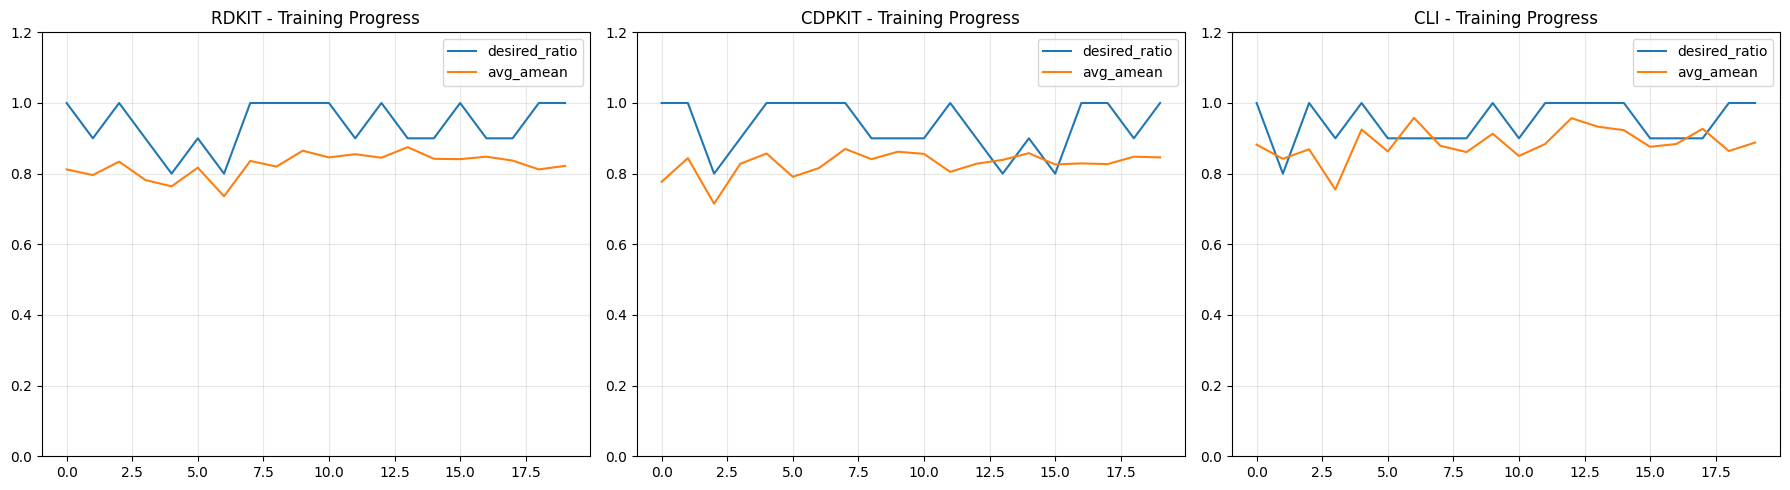

In [10]:
import matplotlib.pyplot as plt

# Create subplots side by side
fig, axes = plt.subplots(1, len(df_results), figsize=(6*len(df_results), 5))
if len(df_results) == 1:
    axes = [axes]  

for idx, row in df_results.iterrows():
    backend = row['backend']
    df_rl = pd.read_csv(row['fit_path'], sep='\t')

    ax = axes[idx]
    df_rl[['desired_ratio', 'avg_amean']].plot.line(ax=ax, title=f'{backend.upper()} - Training Progress')
    ax.set_ylim(0, 1.2) 
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Generating Optimized Molecules

Now we use the trained RL models to generate novel molecules that satisfy our objectives. We'll generate molecules from each backend and compare their scores.

In [11]:
lookup = {name: builder for name, builder, _ in builders}

for row in df_results.itertuples():
    backend = row.backend
    print(f"\n{'='*60}")
    print(f"Generating molecules with {backend.upper()} model")
    print(f"{'='*60}")
    
    # Build environment
    _, env = lookup[backend]()
    
    # Load trained agent
    agent = SequenceRNN(voc, is_lstm=True)
    agent.loadStatesFromFile(row.checkpoint)
    
    # Generate molecules with evaluation
    df_gen = agent.generate(
        num_samples=200, 
        evaluator=env
    )
    
    # Get scorer keys
    scorer_keys = env.getScorerKeys()
    
    # Calculate total score as mean of all scorer columns BEFORE saving
    df_gen['Total'] = df_gen[scorer_keys].mean(axis=1)
    
    # Save generated molecules with Total column
    out_path = row.fit_path.replace('_fit.tsv', '_generated.tsv')
    df_gen.to_csv(out_path, sep='\t', index=False)
    print(f"Saved {len(df_gen)} molecules to: {out_path}")
    
    # Show statistics
    print(f"\nScore Statistics:")
    print(df_gen[scorer_keys + ['Total']].describe())
    print(f"\nDesired molecules: {df_gen['Desired'].sum()} / {len(df_gen)} ({100*df_gen['Desired'].mean():.1f}%)")


Generating molecules with RDKIT model


Generating molecules:   0%|          | 0/200 [00:00<?, ?it/s]

Saved 200 molecules to: /home/ubuntu/DrugEx-ROCS-private/tutorial/rocs/rl_runs_demo/rdkit_rl/CCR2_rdkit_reinforced_generated.tsv

Score Statistics:
       RDKit_Supermol_TanimotoCombo          SA       Total
count                    200.000000  200.000000  200.000000
mean                       0.641725    2.740115    1.690920
std                        0.189861    0.744466    0.364453
min                        0.000000    1.436000    1.026500
25%                        0.590500    2.226000    1.434000
50%                        0.667000    2.572500    1.617000
75%                        0.746250    3.079750    1.889125
max                        1.064000    6.363000    3.490500

Desired molecules: 184.0 / 200 (92.0%)

Generating molecules with CDPKIT model


Generating molecules:   0%|          | 0/200 [00:00<?, ?it/s]

Saved 200 molecules to: /home/ubuntu/DrugEx-ROCS-private/tutorial/rocs/rl_runs_demo/cdpkit_rl/CCR2_cdpkit_reinforced_generated.tsv

Score Statistics:
       CDPKit_ROCS_Supermol_TanimotoCombo          SA       Total
count                          200.000000  200.000000  200.000000
mean                             0.690430    2.699405    1.694918
std                              0.139154    0.717111    0.352567
min                              0.000000    1.336000    1.041500
25%                              0.623500    2.214750    1.448875
50%                              0.698000    2.554500    1.630750
75%                              0.770500    3.103500    1.893500
max                              1.082000    5.414000    3.073000

Desired molecules: 193.0 / 200 (96.5%)

Generating molecules with CLI model


...

Scoring with query file: /home/ubuntu/DrugEx-ROCS-private/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf


Scoring with query file: /home/ubuntu/DrugEx-ROCS-private/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf


Scoring with query file: /home/ubuntu/DrugEx-ROCS-private/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf


Scoring with query file: /home/ubuntu/DrugEx-ROCS-private/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf


Scoring with query file: /home/ubuntu/DrugEx-ROCS-private/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
Saved 200 molecules to: /home/ubuntu/DrugEx-ROCS-private/tutorial/rocs/rl_runs_demo/cli_rl/CCR2_cli_reinforced_generated.tsv

Score Statistics:
        ROCS_CCR2          SA       Total
count  200.000000  200.000000  200.000000
mean     0.789695    2.786240    1.787968
std      0.214310    0.710627    0.346181
min      0.000000    1.586000    1.208500
25%      0.733750    2.252750    1.546125
50%      0.829500    2.678500    1.738750
75%      0.901000    3.177000    1.977625
max      1.165000    6.119000    3.485500

Desired molecules: 189.0 / 200 (94.5%)
